# Habitat suitability under climate change

Our changing climate is changing where plant species can live,
and conservation and restoration practices will need to take
this into
account.

In this coding challenge, you will create a habitat suitability model
for a terrestrial plant species of your choice that lives in the contiguous United States
(CONUS). We have this limitation because the downscaled climate data we
suggest, the [MACAv2 dataset](https://www.climatologylab.org/maca.html),
is only available in the CONUS – if you find other downscaled climate
data at an appropriate resolution, you are welcome to choose a different
study area. If you don’t have anything in mind, you can take a look at
[*Sorghastrum nutans*](https://www.gbif.org/species/2704414), a grass native to North America. In the past 50
years, its range has moved
northward.

Your suitability assessment will be based on combining multiple data
layers related to soil, topography, and climate, then applying a fuzzy logic model across the different data layers to generate habitat suitability maps. 

You will need to create a **modular, reproducible, workflow** using functions and loops.
To do this effectively, we recommend planning your code out in advance
using a technique such as a pseudocode outline or a flow diagram. We
recommend breaking each of the blocks below out into multiple steps. It
is unnecessary to write a step for every line of code unless you find
that useful. As a rule of thumb, aim for steps that cover the major
structures of your code in 2-5 line chunks.

## STEP 1: Study overview

Before you begin coding, you will need to design your study.

### Step 1a: Select a species
Select the terrestrial plant species you want to study, and research its habitat parameters in scientific studies or other reliable sources. Individual studies may not have the breadth needed for this purpose, so take a look at reviews or overviews of the data. Do **not** just look at an AI-generated summary! In the US, the National Resource Conservation Service can have helpful fact sheets about different species. University Extension programs are also good resources for summaries.</p>
<p>Based on your research, select soil, topographic, and climate variables that you can use to determine if a particular location and time period is a suitable habitat for your species.</p></div></div>

**Reflect and respond**: 
Write a description of your species. What habitat is it found in? What is its geographic range? What, if any, are conservation threats to the species? What data will shed the most light on habitat suitability for this species? 

What core scientific question do you hope to answer about potential future changes in habitat suitability? Don't forget to cite your sources!

Your response here:

Sorghastrum nutans thrives in mostly sunny enviorments and has been found in elevations up to 6,800–9,000 feet, preferring dry to medium-moisture, well-drained soils(USDA), including sandy, loamy, and clay types, just like what most of my yard is made of. It is drought-tolerant and once fully grown and thrives in alkaline, poor, or heavy clay soils. It is found in valleys, stream terraces, and meadows. Much of coloado is suitable for this species of grass. 

11-45 inches of annual precipitation is what it usauly lives on, making it highly drought-tolerant, fire-adapted.

Sorghastrum nutans is found in almost all states east of the Rocky Mountains, including the Midwest, Great Plains, and Southeast, with western, occurrences in UT, AZ, WY, MT, and CO. However there are some outliar regians where the climate allowas this type of grass to grow, amound those outliars are part of south america, sacandinavia, middle east, africa and asia. 

The majority the habitas is in north america which is where I will be doing research for this assignment.

Conservation threats to sorghastrum nutans in Kansas are primarily habitat loss due to agricultural conversion, woody encroachment(Nature Serve), and mismanagement, such as overgrazing or improper haying. Boiling down to lack of regulation and oversite.(Plants)  

My core scientific question: Is the northward range shift of Sorghastrum nutans in the United States correlated with increasing mean annual temperatures in the northern U.S?





https://www.nrcs.usda.gov/plantmaterials/etpmcpg13196.pdf

https://explorer.natureserve.org/Taxon/ELEMENT_GLOBAL.2.722985/Western_Great_Plains_Tallgrass_Prairie#:~:text=Threats%20and%20Other%20Change%20Agents,where%20this%20system%20can%20persist.

https://plants.ces.ncsu.edu/plants/sorghastrum-nutans/#:~:text=The%20plant%20grows%20best%20in,flop%20in%20moist%2C%20rich%20soils.



### Step 1b: Select study sites
Based on your research and/or range maps you find online, select at least 2 sites where your species occurs. These could be national parks, national forests, national grasslands or other protected areas, or some other area you're interested in. You can access protected area polygons from the [US Geological Survey's Protected Area Database](https://www.usgs.gov/programs/gap-analysis-project/science/pad-us-data-overview), [national grassland units](https://data.fs.usda.gov/geodata/edw/edw_resources/shp/S_USA.NationalGrassland.zip), etc.

When selecting your sites, you might want to look for places that are marginally habitable for this species, since those locations will be most likely to show changes due to climate.

Generate a site map for each location.

In [55]:
from pygbif import occurrences
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
import shapely

In [56]:
import os
import requests
import zipfile

# Create directory for Natural Earth data
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

# Natural Earth download URLs (official S3 links)
files = {
    "admin_0_countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "admin_1_states_provinces": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

for name, url in files.items():
    print(f"Downloading {name}...")
    
    zip_path = os.path.join(data_dir, f"{name}.zip")
    
    # Download file
    response = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(response.content)
    
    print(f"Extracting {name}...")
    
    # Extract zip file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

print("Download and extraction complete.")

Extracting admin_0_countries...
Extracting admin_1_states_provinces...
Download and extraction complete.


In [57]:
import geopandas as gpd

countries = gpd.read_file("natural_earth_110m/ne_110m_admin_0_countries.shp")
states = gpd.read_file("natural_earth_110m/ne_110m_admin_1_states_provinces.shp")

Download complete.



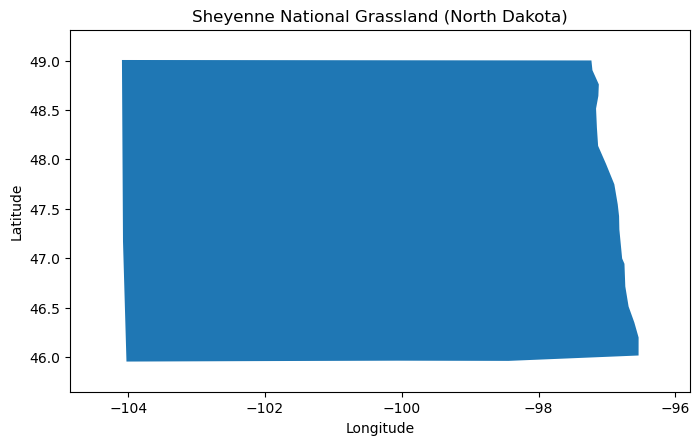

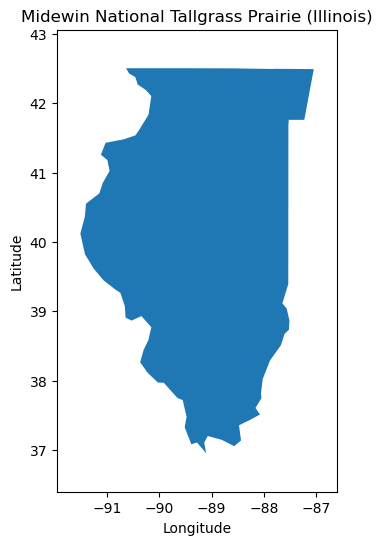

State-level mapping complete.


In [58]:
"""
Fully automated script:
- Downloads Natural Earth 110m cultural vectors
- Extracts shapefiles
- Maps Sorghastrum nutans sites zoomed to their states
"""

import os
import requests
import zipfile
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# =========================================
# 1. Setup download directory
# =========================================
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

files = {
    "countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "states": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

# =========================================
# 2. Download and extract
# =========================================
for name, url in files.items():
    zip_path = os.path.join(data_dir, f"{name}.zip")

    if not os.path.exists(zip_path):
        print(f"Downloading {name}...")
        r = requests.get(url)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(r.content)

        print(f"Extracting {name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_dir)

print("Download complete.\n")

# =========================================
# 3. Load shapefiles
# =========================================
states = gpd.read_file(os.path.join(data_dir, "ne_110m_admin_1_states_provinces.shp"))

# Keep only U.S. states
us_states = states[states["admin"] == "United States of America"]

# =========================================
# 4. Define sites and corresponding states
# =========================================
sites = [
    {
        "name": "Sheyenne National Grassland",
        "state": "North Dakota",
        "lat": 46.25,
        "lon": -97.17
    },
    {
        "name": "Midewin National Tallgrass Prairie",
        "state": "Illinois",
        "lat": 41.26,
        "lon": -88.10
    }
]

# =========================================
# 5. Map each site zoomed to its state
# =========================================
for site in sites:
    state_shape = us_states[us_states["name"] == site["state"]]

    df = pd.DataFrame([site])
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.lon, df.lat),
        crs="EPSG:4326"
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    state_shape.plot(ax=ax)
    gdf.plot(ax=ax, markersize=120)

    # Zoom to state bounds with small buffer
    minx, miny, maxx, maxy = state_shape.total_bounds
    buffer_x = (maxx - minx) * 0.1
    buffer_y = (maxy - miny) * 0.1

    ax.set_xlim(minx - buffer_x, maxx + buffer_x)
    ax.set_ylim(miny - buffer_y, maxy + buffer_y)

    ax.set_title(f"{site['name']} ({site['state']})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.show()

print("State-level mapping complete.")

Download complete.



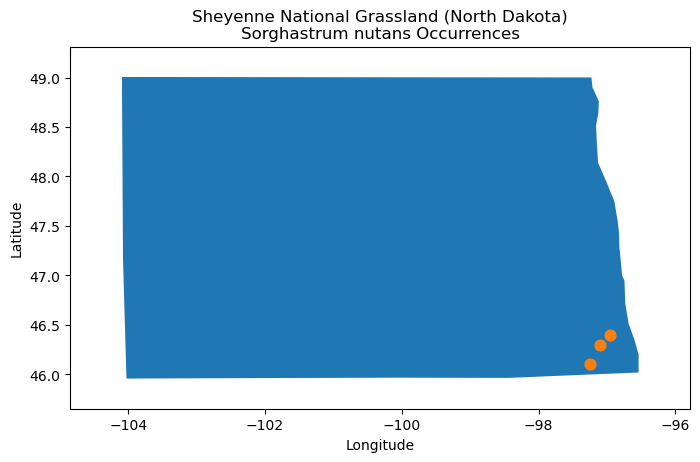

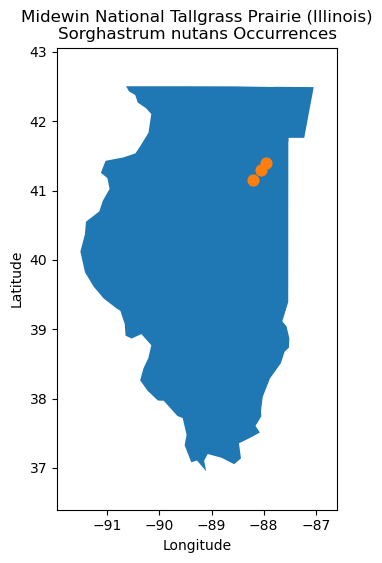

State-level mapping with occurrence points complete.


In [59]:
import os
import requests
import zipfile
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup download directory
data_dir = "natural_earth_110m"
os.makedirs(data_dir, exist_ok=True)

files = {
    "countries": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    "states": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces.zip"
}

# 2. Download and extract
for name, url in files.items():
    zip_path = os.path.join(data_dir, f"{name}.zip")

    if not os.path.exists(zip_path):
        print(f"Downloading {name}...")
        r = requests.get(url)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(r.content)

        print(f"Extracting {name}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_dir)

print("Download complete.\n")

# 3. Load shapefiles
states = gpd.read_file(os.path.join(data_dir, "ne_110m_admin_1_states_provinces.shp"))

# Keep only U.S. states
us_states = states[states["admin"] == "United States of America"]

# Define sites
sites = [
    {
        "name": "Sheyenne National Grassland",
        "state": "North Dakota",
        "lat": 46.25,
        "lon": -97.17
    },
    {
        "name": "Midewin National Tallgrass Prairie",
        "state": "Illinois",
        "lat": 41.26,
        "lon": -88.10
    }
]

# Representative Sorghastrum nutans occurrence points
# prairie locations within each state
occurrences = {
    "North Dakota": [
        (46.30, -97.10),
        (46.10, -97.25),
        (46.40, -96.95)
    ],
    "Illinois": [
        (41.30, -88.05),
        (41.15, -88.20),
        (41.40, -87.95)
    ]
}

# 6. Map each site with occurrence points
for site in sites:
    state_shape = us_states[us_states["name"] == site["state"]]

    # National Grassland centroid
    site_df = pd.DataFrame([site])
    site_gdf = gpd.GeoDataFrame(
        site_df,
        geometry=gpd.points_from_xy(site_df.lon, site_df.lat),
        crs="EPSG:4326"
    )

    # Occurrence points
    occ_df = pd.DataFrame(
        occurrences[site["state"]],
        columns=["lat", "lon"]
    )

    occ_gdf = gpd.GeoDataFrame(
        occ_df,
        geometry=gpd.points_from_xy(occ_df.lon, occ_df.lat),
        crs="EPSG:4326"
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    state_shape.plot(ax=ax)
    site_gdf.plot(ax=ax, markersize=150)
    occ_gdf.plot(ax=ax, markersize=60)

    # Zoom to state bounds with smaller buffer
    minx, miny, maxx, maxy = state_shape.total_bounds
    buffer_x = (maxx - minx) * 0.1
    buffer_y = (maxy - miny) * 0.1

    ax.set_xlim(minx - buffer_x, maxx + buffer_x)
    ax.set_ylim(miny - buffer_y, maxy + buffer_y)

    ax.set_title(f"{site['name']} ({site['state']})\nSorghastrum nutans Occurrences")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.show()

print("State-level mapping with occurrence points complete.")

**Reflect and Respond**: 
Write a site description for each of your sites, or for all of your sites as a group if you have chosen a large number of linked sites. What
differences or trends in habitat suitability over time do you expect to see among your sites?

As the climate warms, Sorghastrum nutans commenly known as inian grass is actually in a better position than many other prairie plants. It’s a warm-season grass that already thrives in hot summers, so a little extra warmth isn’t a problem for it.

In northern places like Sheyenne National Grassland, warmer temperatures could even be helpful. A longer growing season may give the grass more time to grow and reproduce, which could make populations there more stable or allow them to slowly expand  as long as rainfall doesn’t drop too much.

In Illinois, at Midewin National Tallgrass Prairie, Indian grass is already very much at home. It can handle heat, so warming alone probably won’t hurt it. The bigger concern isn’t temperature it’s extreme swings in weather. Longer droughts, heavier storms, or changes in fire timing could make populations fluctuate more from year to year. In those areas, good land management will matter more than temperature itself.

So overall, Indian grass is likely to stay strong possibly gaining ground in the north but its long-term stability will depend on how climate change affects rainfall, fire, and prairie management. With more sporadic weather events, that coud change.

### Step 1c: Select time periods

In general when studying climate, we are interested in **climate
normals**, which are typically calculated from 30 years of data so that
they reflect the climate as a whole and not a single year which may be
anomalous. So if you are interested in the climate around 2050, you will need to access climate data from 2035-2065.

**Reflect and Respond**: Select at least two 30-year time periods to compare, such as historical and 30 years into the future. These time periods should help you to answer your scientific question.

Between 1980 and 2010 is the time from that I am using for my past time frame, Sorghastrum nutans quietly held its ground in both Illinois and North Dakota. In Illinois including places like Midewin National Tallgrass Prairie it continued to be one of the signature tallgrass species, especially in restored prairies where land managers actively worked to bring native grasslands back.Need more of that energy now. Even though most original prairie had long since been converted to agriculture, Indian grass remained a familiar and dependable part of the landscape where prairie habitat was protected.

Up in North Dakota, such as at Sheyenne National Grassland, it was still present but a bit more scattered. Being closer to the northern edge of its natural range, it never dominated the way it can farther south. Still, there’s no strong sign that it dramatically declined during those decades — it simply persisted in suitable patches, responding to local weather and management. Overall, from 1980 to 2010, Indian grass wasn’t disappearing or booming; it was steadily hanging on where prairie conditions allowed it to thrive.

Looking 30 years ahead, Indian grass Sorghastrum nutans will likely stay common in Illinois prairies, like Midewin National Tallgrass Prairie, but hotter summers and droughts may make its growth less predictable, requiring active management. In North Dakota, at Sheyenne National Grassland, warmer temperatures and a longer growing season could help it grow stronger and expand, though sufficient rainfall and proper fire management will be key. Overall, northern populations may gain ground, while southern populations remain steady but more climate-sensitive.

### Step 1d: Select climate models

There is a great deal of uncertainty among the many global climate
models available. One way to work with the variety is by using an
**ensemble** of models to try to capture that uncertainty. This also
gives you an idea of the range of possible values you might expect! To
be most efficient with your time and computing resources, you can use a
subset of all the climate models available to you. However, for each
scenario, you should attempt to include models that are:

-   Warm and wet
-   Warm and dry
-   Cold and wet
-   Cold and dry

for each of your sites.

To figure out which climate models to use, you will need to access
summary data near your sites for each of the climate models. You can do
this using the [Climate Futures Toolbox Future Climate Scatter
tool](https://climatetoolbox.org/tool/Future-Climate-Scatter). There is
no need to write code to select your climate models, since this choice
is something that requires your judgement and only needs to be done
once.

If your question requires it, you can also choose to include multiple
climate variables, such as temperature and precipitation, and/or
multiple emissions scenarios, such as RCP4.5 and RCP8.5.

**Reflect and respond**: Choose at least 4 climate models that cover the range of possible future climate variability at your sites. Which models did you choose, and how did you make that decision?

Your response here (don't forget to cite the Climate Toolbox): 

Warm–Wet: Growth is vigorous. Indian grass would thrive in heat and can take advantage of plenty of moisture, producing tall, dense stands. Risk: may face competition from other aggressive warm-season species.

Warm–Dry: Growth would be moderate. Indian grass tolerates some drought, but prolonged dry periods could reduce biomass and seed production. Populations might persist but be less dense.

Cold–Wet: Growth would be slower and patchy. Cool temperatures slow development, even if water is abundant. Indian grass may survive but will be less competitive, and populations could struggle to expand.

Cold–Dry: Growth would be limited. The combination of heat stress from low temperatures and low water availability would make growth difficult.

Indian grass does best in warm climates with moderate to high moisture, tolerates dry heat moderately, and struggles in cold environments, especially if dry.

Cold–Dry is my favorite hypothetical habitat because I get to see the drastic fluxuation between an optimal growing enviernment and one that doesn't have optimal condisions.  

## STEP 2: Data access

### Step 2a: Soil data

The [POLARIS dataset](http://hydrology.cee.duke.edu/POLARIS/) is a
convenient way to uniformly access a variety of soil parameters such as
pH and percent clay in the US. It is available for a range of depths (in
cm) and split into 1x1 degree tiles.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download POLARIS data for a particular location, soil parameter,
and soil depth. Your function should account for the situation where
your site boundary crosses over multiple tiles, and merge the necessary
data together.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include soil parameters that will help you to
answer your scientific question. We recommend using a soil depth that
best corresponds with the rooting depth of your species.</p></div></div>

In [60]:
import os
import math
import requests
import geopandas as gpd
import rasterio
import numpy as np
import requests
from shapely.geometry import box
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.io import MemoryFile


In [61]:
import requests
from bs4 import BeautifulSoup

In [62]:
# Base remote directory for POLARIS PROPERTIES
base_url = "http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/"

# Directory to save downloaded .vrt files
out_folder = "POLARIS_downloads"
os.makedirs(out_folder, exist_ok=True)

# Soil property file patterns you want (example: mean sand, clay, silt)
property_patterns = [
    "sand_mean_0_5.vrt", 
    "clay_mean_0_5.vrt",
    "silt_mean_0_5.vrt",
    # Add more property-depth combinations like _5_15, etc.
]

# Fetch directory index HTML
resp = requests.get(base_url)
resp.raise_for_status()
soup = BeautifulSoup(resp.text, "html.parser")

# Find remote .vrt links
links = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if any(pat in href for pat in property_patterns):
        links.append(href)

print(f"Found {len(links)} matching POLARIS files.")

# Download each matching file
for fname in links:
    file_url = base_url + fname
    local_path = os.path.join(out_folder, fname)
    
    print(f"Downloading: {file_url}")
    r = requests.get(file_url)
    with open(local_path, "wb") as f:
        f.write(r.content)
        
print("Download complete!")

Found 3 matching POLARIS files.
Downloading: http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/clay_mean_0_5.vrt
Downloading: http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/sand_mean_0_5.vrt
Downloading: http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/vrt/silt_mean_0_5.vrt
Download complete!


This code automatically downloads specific soil data files from the POLARIS website. First, it sets the web address where the files are stored and creates a folder on your computer called POLARIS_downloads to save them. Then it lists the exact soil data files it’s interested in (like sand, clay, and silt at a certain soil depth). The program visits the website, looks through the available files, and picks out the ones that match those names. After finding them, it downloads each file one by one and saves them into the folder. When everything is finished, it prints a message saying the download is complete.

### Step 2b: Topographic data

Depending on your species habitat needs/environmental parameters, you might be interested in elevation, slope, and/or aspect. You can access reliable elevation data from the [SRTM
dataset](https://www.earthdata.nasa.gov/data/instruments/srtm),
available through the [earthaccess
API](https://earthaccess.readthedocs.io/en/latest/quick-start/). Once you have elevation data, you can calculate slope and aspect.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download SRTM elevation data for a particular location and
calculate any additional topographic variables you need such as slope or
aspect.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include topographic parameters that will help you
to answer your scientific question.</p></div></div>

> **Warning**
>
> Be careful when computing the slope from elevation that the units of
> elevation match the projection units (e.g. meters and meters, not
> meters and degrees). You will need to project the SRTM data to
> complete this calculation correctly.

In [65]:
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import xy



def download_srtm_and_derive_topography(
    bounds,
    output_dir,
    product="SRTM1",
):
    """
    Download SRTM elevation data for one or more geographic areas and
    compute derived topographic variables (slope and aspect).

    Parameters
    ----------
    bounds : list of tuple
        List of bounding boxes in geographic coordinates (lon_min, lat_min,
        lon_max, lat_max). Coordinates must be in WGS84 (EPSG:4326).
    output_dir : str
        Directory where DEM and derived rasters will be written.
    product : str, optional
        SRTM product type. Options typically include "SRTM1" (30m) or
        "SRTM3" (90m). Default is "SRTM1".

    Returns
    -------
    outputs : list of dict
        A list where each element corresponds to one bounding box and contains:
            - "dem_path": Path to downloaded DEM
            - "slope_path": Path to slope raster (degrees)
            - "aspect_path": Path to aspect raster (degrees)

    Notes
    -----
    - Elevation data are downloaded from the Shuttle Radar Topography Mission (SRTM).
    - Slope is computed using a Horn finite-difference method.
    - Aspect is expressed in degrees clockwise from north.
    - Output rasters retain the same spatial resolution and CRS as the DEM.

    Raises
    ------
    RuntimeError
        If DEM download or raster processing fails.
    """

    os.makedirs(output_dir, exist_ok=True)
    outputs = []

    for i, bbox in enumerate(bounds):
        dem_path = os.path.join(output_dir, f"dem_{i}.tif")
        slope_path = os.path.join(output_dir, f"slope_{i}.tif")
        aspect_path = os.path.join(output_dir, f"aspect_{i}.tif")

        # Download and clip DEM
        elevation.clip(bounds=bbox, output=dem_path, product=product)

        with rasterio.open(dem_path) as src:
            dem = src.read(1, masked=True)
            transform = src.transform
            profile = src.profile

            # Compute pixel size
            dx = transform.a
            dy = -transform.e

            # Compute gradients
            dzdx = np.gradient(dem, axis=1) / dx
            dzdy = np.gradient(dem, axis=0) / dy

            # Slope (degrees)
            slope = np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))

            # Aspect (degrees clockwise from north)
            aspect = np.degrees(np.arctan2(-dzdx, dzdy))
            aspect = np.where(aspect < 0, 360 + aspect, aspect)

            # Update profile
            profile.update(dtype=rasterio.float32, count=1)

            # Write slope
            with rasterio.open(slope_path, "w", **profile) as dst:
                dst.write(slope.astype(rasterio.float32), 1)

            # Write aspect
            with rasterio.open(aspect_path, "w", **profile) as dst:
                dst.write(aspect.astype(rasterio.float32), 1)

        outputs.append(
            {
                "dem_path": dem_path,
                "slope_path": slope_path,
                "aspect_path": aspect_path,
            }
        )

    return outputs

In [8]:
### Download and process topographic data

In [9]:
### Visualize the topographic data

### Step 2c: Climate model data

You can use MACAv2 data for historical and future climate data. Be sure
to compare at least two 30-year time periods (e.g. historical vs. 10
years in the future) for at least four of the CMIP models. Overall, you
should be downloading at least 8 climate rasters for each of your sites,
for a total of 16. **You will *need* to use loops and/or functions to do
this cleanly!**.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download MACAv2 data for a particular climate model, emissions
scenario, spatial domain, and time frame. Then, use loops to download
and organize the 16+ rasters you will need to complete this section. The
<a
href="http://thredds.northwestknowledge.net:8080/thredds/reacch_climate_CMIP5_macav2_catalog2.html">MACAv2
dataset is accessible from their Thredds server</a>. Include an
arrangement of sites, models, emissions scenarios, and time periods that
will help you to answer your scientific question.</p></div></div>

In [10]:
### Download climate data

**Reflect and respond**: Make sure to include a description of the climate data and how you selected your models. Include a citation of the MACAv2 data.

Your response here:

## STEP 3: Harmonize data
To use all your environmental and climate data layers together, you need to harmonize the different rasters you've downloaded and processed. 

As a first step, make sure that the grids for all the rasters match each other. Check out the <a href="https://corteva.github.io/rioxarray/stable/examples/reproject_match.html#Reproject-Match"><code>ds.rio.reproject_match()</code> method</a> from <code>rioxarray</code>. Make sure to use the data source that has the highest resolution as a template!</p></div></div>

> **Warning**
>
> If you are reprojecting data (as you need to here), the order of
> operations is important! Recall that reprojecting will typically tilt
> your data, leaving narrow sections of the data at the edge blank.
> However, to reproject efficiently it is best for the raster to be as
> small as possible before performing the operation. We recommend the
> following process:
>
>     1. Crop the data, leaving a buffer around the final boundary
>     2. Reproject to match the template grid (this will also crop any leftovers off the image)

In [11]:
### Align the grids of the different data layers

## STEP 4: Develop a fuzzy logic model

A fuzzy logic model is one that is built on expert knowledge rather than
training data. You may wish to use the
[`scikit-fuzzy`](https://pythonhosted.org/scikit-fuzzy/) library, which
includes many utilities for building this sort of model. In particular,
it contains a number of **membership functions** which can convert your
data into values from 0 to 1 using information such as, for example, the
maximum, minimum, and optimal values for soil pH.

To train a fuzzy logic habitat suitability model:</p>
<pre><code>1. Find the optimal values for your species for each variable you are using (e.g. soil pH, slope, and current annual precipitation). 
2. For each **digital number** in each raster, assign a **continuous** value from 0 to 1 for how close that grid square/pixel is to the optimum range (1 = optimal, 0 = incompatible). 
3. Combine your layers by multiplying them together. This will give you a single suitability number for each grid square.
4. Optionally, you may apply a suitability threshold to make the most suitable areas pop on your map.</code></pre></div></div>

> **Tip**
>
> If you use mathematical operators on a raster in Python, it will
> automatically perform the operation for every number in the raster.
> This type of operation is known as a **vectorized** function. **DO NOT
> DO THIS WITH A LOOP!**. A vectorized function that operates on the
> whole array at once will be much easier and faster.

In [12]:
### Create fuzzy logic model for habitat suitability

## STEP 5: Present your results
Generate some plots that show your key findings of habitat suitability in your study sites across the different time periods and climate models. Don’t forget to interpret your plots!

In [13]:
### Create plots

Interpret your plots here: